In [2]:
!pip install PyMuPDF tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 98.2 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from spacy.lang.en import English
import requests
import fitz
import random
from tqdm.auto import tqdm
from time import perf_counter as timer
import nltk
from nltk import sent_tokenize
nltk.download('punkt')
import textwrap
import random
from sentence_transformers import util, SentenceTransformer
import torch
from time import perf_counter as timer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import AutoProcessor, AutoModelForVision2Seq
from PIL import Image
import torch
import requests
import torch
from PIL import Image
from transformers import MllamaForConditionalGeneration, AutoProcessor
import random

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 1. Document/text processing and embedding creation

Steps:
1. Import PDF document.
2. Process text for embedding (e.g. split into chunks of sentences).
3. Embed text chunks with embedding model.
4. Save embeddings to file for later.


In [5]:
#Testing on one document first
pdf_path = '/content/drive/MyDrive/fMRIwork/ales.pdf'

if not os.path.exists(pdf_path):
  raise FileNotFoundError(f"PDF file not found at path: {pdf_path}")

In [6]:
def text_formatter(text: str) -> str:
  """ Does minor formatting on text """
  cleaned_text = text.replace("\n", " ").strip()
  return cleaned_text

def open_and_read_pdf(pdf_path: str) -> str:

  doc = fitz.open(pdf_path)
  pages_and_text = []
  for page_num,page in tqdm(enumerate(doc)):
    text = page.get_text()
    text = text_formatter(text)
    pages_and_text.append({"page_number": page_num,
                           "page_char_count": len(text),
                           "page_word_count": len(text.split(" ")),         # rough word count
                           "page_setence_count_raw": len(text.split(". ")), # rough sentence count
                           "page_token_count": len(text) / 4, # 1 token = ~4 characters ~ rough token count
                           "text": text})

  return pages_and_text

pages_and_texts = open_and_read_pdf(pdf_path=pdf_path)
pages_and_texts[:2]

0it [00:00, ?it/s]

[{'page_number': 0,
  'page_char_count': 4142,
  'page_word_count': 627,
  'page_setence_count_raw': 29,
  'page_token_count': 1035.5,
  'text': 'Page 1 of 4 © Annals of Laparoscopic and Endoscopic Surgery. All rights reserved.   Ann Laparosc Endosc Surg 2020;5:15 | http://dx.doi.org/10.21037/ales.2020.02.06 Introduction In the United States, gallstone disease remains a prevalent  condition affecting over 20 to 25 million Americans,  representing 10–15% of the population (1,2). Although not  every patient with gallstones will manifest symptoms or  require intervention, laparoscopic cholecystectomy (LC),  which accounts for 90% of all cholecystectomies, remains  one of the most commonly performed procedures— conservatively numbering 750,000 per year (3). Since its  introduction in the 1980s and subsequent adoption, LC  has become the standard of care due to its advantages of  reduced cost and hospital length of stay, and increased  patient satisfaction (4,5). Overall, LC is considered a

In [7]:
df = pd.DataFrame(pages_and_texts)
df.head()

,page_number,page_char_count,page_word_count,page_setence_count_raw,page_token_count,text
0,0,4142,627,29,1035.50,Page 1 of 4 © Annals of Laparoscopic and Endos...
1,1,4339,759,28,1084.75,"Annals of Laparoscopic and Endoscopic Surgery,..."
2,2,5465,963,37,1366.25,"Annals of Laparoscopic and Endoscopic Surgery,..."
3,3,4134,628,63,1033.50,"Annals of Laparoscopic and Endoscopic Surgery,..."


In [8]:
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_setence_count_raw,page_token_count
count,4.00,4.00,4.00,4.00,4.00
mean,1.50,4520.00,744.25,39.25,1130.00
std,1.29,637.09,158.46,16.34,159.27
min,0.00,4134.00,627.00,28.00,1033.50
25%,0.75,4140.00,627.75,28.75,1035.00
50%,1.50,4240.50,693.50,33.00,1060.12
75%,2.25,4620.50,810.00,43.50,1155.12
max,3.00,5465.00,963.00,63.00,1366.25


In [9]:
nlp = English()

# Add a sentencizer pipeline
nlp.add_pipe("sentencizer")

doc = nlp("This is a sentence. This another sentence. I like elephants.")
assert len(list(doc.sents)) == 3

list(doc.sents)

[This is a sentence., This another sentence., I like elephants.]

In [10]:
for item in tqdm(pages_and_texts):
    item["sentences"] = list(nlp(item["text"]).sents)

    # Make sure all sentences are strings
    item["sentences"] = [str(sentence) for sentence in item["sentences"]]

    item["page_sentence_count_spacy"] = len(item["sentences"])

  0%|          | 0/4 [00:00<?, ?it/s]

In [11]:
random.sample(pages_and_texts, k=1)

[{'page_number': 0,
  'page_char_count': 4142,
  'page_word_count': 627,
  'page_setence_count_raw': 29,
  'page_token_count': 1035.5,
  'text': 'Page 1 of 4 © Annals of Laparoscopic and Endoscopic Surgery. All rights reserved.   Ann Laparosc Endosc Surg 2020;5:15 | http://dx.doi.org/10.21037/ales.2020.02.06 Introduction In the United States, gallstone disease remains a prevalent  condition affecting over 20 to 25 million Americans,  representing 10–15% of the population (1,2). Although not  every patient with gallstones will manifest symptoms or  require intervention, laparoscopic cholecystectomy (LC),  which accounts for 90% of all cholecystectomies, remains  one of the most commonly performed procedures— conservatively numbering 750,000 per year (3). Since its  introduction in the 1980s and subsequent adoption, LC  has become the standard of care due to its advantages of  reduced cost and hospital length of stay, and increased  patient satisfaction (4,5). Overall, LC is considered a

In [12]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_setence_count_raw,page_token_count,page_sentence_count_spacy
count,4.00,4.00,4.00,4.00,4.00,4.00
mean,1.50,4520.00,744.25,39.25,1130.00,38.25
std,1.29,637.09,158.46,16.34,159.27,18.01
min,0.00,4134.00,627.00,28.00,1033.50,24.00
25%,0.75,4140.00,627.75,28.75,1035.00,27.00
50%,1.50,4240.50,693.50,33.00,1060.12,32.50
75%,2.25,4620.50,810.00,43.50,1155.12,43.75
max,3.00,5465.00,963.00,63.00,1366.25,64.00


### Chunking sentences
We'll start with 10 sentences but continue to experiment to see what gives us the best results. We'll first start with writing this in pure Python, but can experiment with frameworks such as LangChain later on.

In [13]:
# Define split size
num_sentence_chunk_size = 10

def split_list(input_list: list[str], slice_size: int=num_sentence_chunk_size) -> list[list[str]]:
  """ Split lists of texts recursively into chunk size """
  return [input_list[i:i+slice_size] for i in range(0, len(input_list), slice_size)]

test_list = list(range(25))
split_list(test_list)

[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [20, 21, 22, 23, 24]]

In [14]:
for item in tqdm(pages_and_texts):
    item["sentence_chunks"] = split_list(item["sentences"], slice_size=num_sentence_chunk_size)
    item["num_chunks"] = len(item["sentence_chunks"])

  0%|          | 0/4 [00:00<?, ?it/s]

In [15]:
random.sample(pages_and_texts, k=1)

[{'page_number': 1,
  'page_char_count': 4339,
  'page_word_count': 759,
  'page_setence_count_raw': 28,
  'page_token_count': 1084.75,
  'text': 'Annals of Laparoscopic and Endoscopic Surgery, 2020 Page 2 of 4 © Annals of Laparoscopic and Endoscopic Surgery. All rights reserved.   Ann Laparosc Endosc Surg 2020;5:15 | http://dx.doi.org/10.21037/ales.2020.02.06 (T1 position) (Figure 1). In patients with prior periumbilical  midline incisions, an alternative access site is used, either  closed with a Verres needle in the right upper quadrant  mid-clavicular below the liver or left upper quadrant  (Palmer’s point) or via an open epigastric incision. In the  obese patient, a closed Verres needle access is obtained  just to the right of the midline 15 cm below the xiphoid  since the umbilicus is displaced inferiorly in these patients;  this allows the camera port to be positioned for adequate  visualization of the dissection site. After creation of the  pneumoperitoneum, 5 mm ports are plac

In [16]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_setence_count_raw,page_token_count,page_sentence_count_spacy,num_chunks
count,4.00,4.00,4.00,4.00,4.00,4.00,4.00
mean,1.50,4520.00,744.25,39.25,1130.00,38.25,4.25
std,1.29,637.09,158.46,16.34,159.27,18.01,1.89
min,0.00,4134.00,627.00,28.00,1033.50,24.00,3.00
25%,0.75,4140.00,627.75,28.75,1035.00,27.00,3.00
50%,1.50,4240.50,693.50,33.00,1060.12,32.50,3.50
75%,2.25,4620.50,810.00,43.50,1155.12,43.75,4.75
max,3.00,5465.00,963.00,63.00,1366.25,64.00,7.00


In [17]:
# Split each chunk into its own item
pages_and_chunks = []
for item in tqdm(pages_and_texts):
    for sentence_chunk in item["sentence_chunks"]:
        chunk_dict = {}
        chunk_dict["page_number"] = item["page_number"]

        # join the list of sentences into one paragraph
        joined_sentence_chunk = "".join(sentence_chunk).replace("  ", " ").strip()
        joined_sentence_chunk = re.sub(r'\.([A-Z])', r'. \1', joined_sentence_chunk)

        chunk_dict["sentence_chunk"] = joined_sentence_chunk

        chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)
        chunk_dict["chunk_word_count"] = len([word for word in joined_sentence_chunk.split(" ")])
        chunk_dict["chunk_token_count"] = len(joined_sentence_chunk) / 4 # 1 token = ~4 chars

        pages_and_chunks.append(chunk_dict)

len(pages_and_chunks)

  0%|          | 0/4 [00:00<?, ?it/s]

17

In [18]:
random.sample(pages_and_chunks, k=1)

[{'page_number': 2,
  'sentence_chunk': 'If a stone is visualized in the bile duct, then the decision should be made whether to attempt a trans-cystic common bile duct exploration, laparoscopic choledochotomy, or referral for postoperative ERCP, according to surgeon expertise and preference. Once a satisfactory cholangiogram is obtained, the cholangiogram catheter is removed, and the cystic duct is doubly clipped and divided. As stated above, if there is concern about the security of the clips on the cystic duct, a pre-tied loop suture should be used to secure the duct instead. Step 5: Gallbladder separation from the liver bed Following division of the cystic duct, retrograde dissection of the gallbladder from the liver bed is performed. In our institution, we use an L-hook monopolar energy device to dissect gallbladder off the liver. Care should be taken to stay in the plane between the gallbladder and liver bed. Entry into the liver bed may result in bleeding and/or bile leakage from

In [19]:
df = pd.DataFrame(pages_and_chunks)
df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,17.00,17.00,17.00,17.00
mean,1.88,1045.88,158.41,261.47
std,1.17,532.80,87.36,133.20
min,0.00,279.00,33.00,69.75
25%,1.00,482.00,64.00,120.50
50%,2.00,896.00,153.00,224.00
75%,3.00,1648.00,244.00,412.00
max,3.00,1710.00,283.00,427.50


In [20]:
df

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count
0,0,Page 1 of 4 © Annals of Laparoscopic and Endos...,1648,232,412.00
1,0,In order to enhance the safety of cholecystect...,1690,249,422.50
2,0,Bile duct injury can convert a potentially out...,749,93,187.25
3,1,"Annals of Laparoscopic and Endoscopic Surgery,...",1666,258,416.50
4,1,"Using T3, the surgeon can manipulate the neck ...",1710,283,427.50
5,1,"At this juncture, identification of aberrant a...",896,153,224.00
6,2,"Annals of Laparoscopic and Endoscopic Surgery,...",1415,225,353.75
7,2,If an intraoperative cholangiogram is to be pe...,1466,244,366.50
8,2,"If a stone is visualized in the bile duct, the...",1651,259,412.75
9,2,Just prior to complete disassociation of the g...,845,150,211.25


### Filter chunks for text that may contain irrelevant information to the task (citing, formatting, etc.)

In [21]:
#TODO

In [22]:
#TODO

In [23]:
#TODO

### Embedding text chunks

In [24]:
embedding_model = SentenceTransformer('pritamdeka/BioBERT-mnli-snli-scinli-scitail-mednli-stsb')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/691 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [25]:
sentences = ["This is a sentence.",
             "This is another sentence.",
             "The patient was sent to surgery.",
             "The patient left the operating room"]

In [26]:
# Sentences are encoded
embeddings = embedding_model.encode(sentences)
embeddings_dict = dict(zip(sentences, embeddings))

for sentence, embedding in embeddings_dict.items():
    print(f"Sentence: {sentence}")
    print(f"Embedding: {embedding}")
    print("")

Sentence: This is a sentence.
Embedding: [-2.92263478e-01 -5.02286144e-02  7.20096648e-01 -9.39667761e-01
  7.32690036e-01  3.93071592e-01  3.96621644e-01 -1.05020988e+00
 -3.01180273e-01 -3.57151031e-01  5.50141156e-01 -9.40424263e-01
 -1.14271653e+00  2.90342718e-02  4.80402440e-01 -6.16672099e-01
  2.35545188e-01 -5.01686692e-01 -1.25742328e+00 -3.34996909e-01
 -1.97036024e-02  4.65498716e-01 -1.67026296e-01  4.97920886e-02
 -8.78444389e-02 -4.60825592e-01  5.15391588e-01  4.69749361e-01
  1.04201950e-01 -5.82003891e-01 -3.23917240e-01 -6.35203183e-01
 -1.13683872e-01  1.95484191e-01  5.27970083e-02 -4.05764669e-01
 -6.27723411e-02  7.43378580e-01 -7.36642003e-01 -1.52477777e+00
 -2.28776932e-02 -4.29958165e-01  2.68643618e-01 -4.05726433e-02
  2.70451754e-01 -3.90830040e-01  2.82255886e-03 -3.04065086e-02
  2.55084466e-02 -8.73024881e-01  1.34046078e+00  4.36919779e-01
 -2.14803949e-01  1.71193719e+00  8.32339898e-02 -6.23443007e-01
 -2.70282716e-01  2.91764826e-01  1.21085739e+00 

In [27]:
embeddings[0].shape

(768,)

In [28]:
%%time

#embedding_model.to("cuda")

for item in tqdm(pages_and_chunks):
    item["embedding"] = embedding_model.encode(item["sentence_chunk"])


  0%|          | 0/17 [00:00<?, ?it/s]

CPU times: user 238 ms, sys: 8.43 ms, total: 246 ms
Wall time: 259 ms


In [29]:
#Batch processing for large sets of data
%%time
text_chunks = [item["sentence_chunk"] for item in pages_and_chunks]

# Embed all texts in batches
text_chunk_embeddings = embedding_model.encode(text_chunks,
                                               batch_size=2, # experiment when you get to large amounts of data
                                               convert_to_tensor=True)
text_chunk_embeddings

CPU times: user 106 ms, sys: 10.9 ms, total: 117 ms
Wall time: 175 ms


tensor([[ 0.1842,  0.4119, -0.2846,  ..., -0.0294, -0.4211,  0.4894],
        [ 0.1400, -0.1210,  0.2787,  ...,  0.5321, -0.4957,  0.4874],
        [ 0.3040,  0.0874,  0.0370,  ...,  0.7691, -0.1119,  0.4464],
        ...,
        [-0.0104,  0.0022, -0.1226,  ...,  0.3275, -0.0128,  0.0946],
        [ 0.1561, -0.4778,  0.1847,  ...,  0.5321, -0.1883,  0.4878],
        [ 0.3355,  0.2459,  0.2123,  ...,  0.1675, -0.6036,  0.1923]],
       device='cuda:0')

### Save embeddings to file (Look into vector database storage instead)

In [30]:
text_chunks_and_embeddings_df = pd.DataFrame(pages_and_chunks)
embeddings_df_save_path = "/content/drive/MyDrive/fMRIwork/text_chunks_and_embeddings_df.csv"
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

In [31]:
text_chunks_and_embedding_df = pd.read_csv(embeddings_df_save_path)
text_chunks_and_embedding_df.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,0,Page 1 of 4 © Annals of Laparoscopic and Endos...,1648,232,412.00,[ 1.84193909e-01 4.11859602e-01 -2.84561664e-...
1,0,In order to enhance the safety of cholecystect...,1690,249,422.50,[ 1.40045151e-01 -1.20981194e-01 2.78680533e-...
2,0,Bile duct injury can convert a potentially out...,749,93,187.25,[ 3.04045558e-01 8.73852894e-02 3.70028540e-...
3,1,"Annals of Laparoscopic and Endoscopic Surgery,...",1666,258,416.50,[ 1.18772918e-03 5.48459530e-01 4.33360636e-...
4,1,"Using T3, the surgeon can manipulate the neck ...",1710,283,427.50,[ 7.87784457e-02 6.88023210e-01 -6.59858957e-...


RAG - Search and Answer

In [32]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [33]:
text_chunks_and_embedding_df["embedding"] = text_chunks_and_embedding_df["embedding"].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))
pages_and_chunks = text_chunks_and_embedding_df.to_dict(orient="records")

embeddings = torch.tensor(np.array(text_chunks_and_embedding_df["embedding"].tolist()), dtype=torch.float32).to(device)
embeddings.shape

torch.Size([17, 768])

In [34]:
query = "Gallbladder Removal"

print(f"Query: {query}")

query_embedding = embedding_model.encode(query, convert_to_tensor=True)

start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b=embeddings)[0]
end_time = timer()

print(f"Time taken to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

# Get the top-k results
top_results_dot_product = torch.topk(dot_scores, k=5)
top_results_dot_product

Query: Gallbladder Removal
Time taken to get scores on 17 embeddings: 0.01178 seconds.


torch.return_types.topk(
values=tensor([78.2386, 74.9814, 72.3064, 68.1990, 55.3737], device='cuda:0'),
indices=tensor([9, 8, 4, 7, 2], device='cuda:0'))

In [35]:
def print_wrapped(text, wrap_length=80):
    wrapped_text = textwrap.fill(text, wrap_length)
    print(wrapped_text)

In [36]:
print(f"Query: '{query}'\n")
print("Results:")


for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    print(f"Score: {score:.4f}")
    print("Text:")
    print_wrapped(pages_and_chunks[idx]["sentence_chunk"])
    print(f"Page number: {pages_and_chunks[idx]['page_number']}")
    print("\n")

Query: 'Gallbladder Removal'

Results:
Score: 78.2386
Text:
Just prior to complete disassociation of the gallbladder from its bed, the last
attachment should be left in place to allow for retraction of the liver cephalad
and clear visualization of the cystic plate to allow for any needed hemostasis.
The liver bed is irrigated and any blood or bile or aspirated from the field.
The gallbladder is then placed in an entrapment bag and removed at the 10–12 mm
port site. Step 6: Specimen and port removal      Once the specimen is in the
bag, it can be removed at the 10 mm port site whether at the umbilicus or
epigastric region. These steps are summarized in our video (Video 1). Some
enlargement of the skin and fascial opening may be needed, especially if there
are multiple or larger stones or a thickened gallbladder. Once the specimen is
removed, all ports are vented to eliminate any residual CO2 gas.
Page number: 2


Score: 74.9814
Text:
If a stone is visualized in the bile duct, then the d

In [37]:
#Add Reranker model
reranker_model_name = "BAAI/bge-reranker-large"
reranker_tokenizer = AutoTokenizer.from_pretrained(reranker_model_name)
reranker_model = AutoModelForSequenceClassification.from_pretrained(reranker_model_name)

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

In [38]:
reranker_model.eval()

XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 1024, padding_idx=1)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=1024, ou

In [39]:
query = "Gallbladder Removal"
print(f"Query: '{query}'")


query_embedding = embedding_model.encode(query, convert_to_tensor=True)
start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b=embeddings)[0]
end_time = timer()
print(f"Time taken to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

#Get top-k candidates
top_k = 5
top_results = torch.topk(dot_scores, k=top_k)
top_indices = top_results.indices.tolist()
candidate_chunks = [pages_and_chunks[i]["sentence_chunk"] for i in top_indices]

#Prepare reranker input pairs
rerank_inputs = [(query, chunk) for chunk in candidate_chunks]
tokenized = reranker_tokenizer(rerank_inputs, padding=True, truncation=True, return_tensors="pt")

#Compute reranker scores
with torch.no_grad():
    rerank_scores = reranker_model(**tokenized).logits.squeeze(-1)


reranked = sorted(zip(rerank_scores, top_indices), key=lambda x: x[0], reverse=True)


print("\n Final Reranked Results:\n")
for score, idx in reranked:
    print(f"Rerank Score: {score:.4f}")
    print("Text:")
    print_wrapped(pages_and_chunks[idx]["sentence_chunk"])
    print(f"Page number: {pages_and_chunks[idx]['page_number']}")
    print("\n")


Query: 'Gallbladder Removal'
Time taken to get scores on 17 embeddings: 0.00020 seconds.

 Final Reranked Results:

Rerank Score: 4.1477
Text:
Just prior to complete disassociation of the gallbladder from its bed, the last
attachment should be left in place to allow for retraction of the liver cephalad
and clear visualization of the cystic plate to allow for any needed hemostasis.
The liver bed is irrigated and any blood or bile or aspirated from the field.
The gallbladder is then placed in an entrapment bag and removed at the 10–12 mm
port site. Step 6: Specimen and port removal      Once the specimen is in the
bag, it can be removed at the 10 mm port site whether at the umbilicus or
epigastric region. These steps are summarized in our video (Video 1). Some
enlargement of the skin and fascial opening may be needed, especially if there
are multiple or larger stones or a thickened gallbladder. Once the specimen is
removed, all ports are vented to eliminate any residual CO2 gas.
Page num

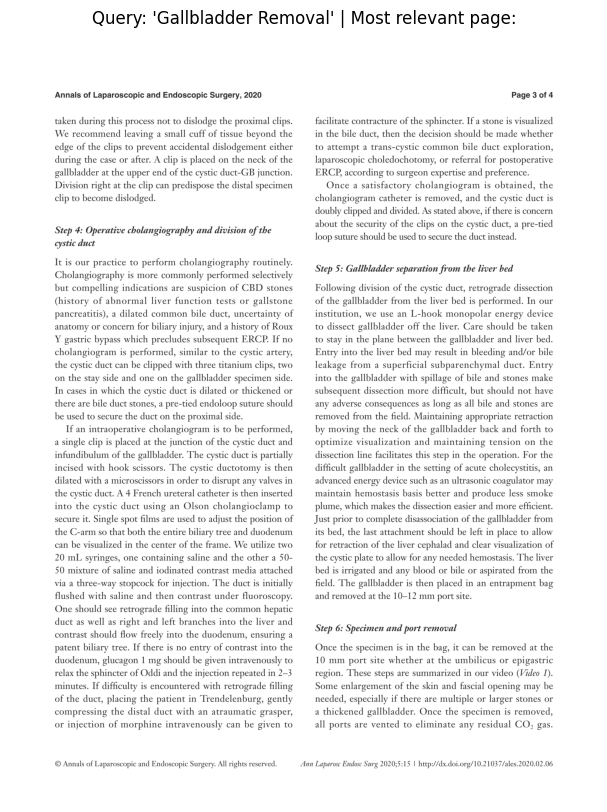

In [40]:
# Open PDF and load target page
pdf_path
doc = fitz.open(pdf_path)
target_page_num = pages_and_chunks[reranked[0][1]]['page_number']
page = doc.load_page(target_page_num)

# Get the image of the page
img = page.get_pixmap(dpi=300)

doc.close()

# Convert the Pixmap to a numpy array
img_array = np.frombuffer(img.samples_mv,
                          dtype=np.uint8).reshape((img.h, img.w, img.n))


plt.figure(figsize=(13, 10))
plt.imshow(img_array)
plt.title(f"Query: '{query}' | Most relevant page:")
plt.axis('off')
plt.show()

Try with cosine similarity as well

In [41]:
def retrieve_relevant_resources(query: str,
                                embeddings: torch.tensor,
                                model: SentenceTransformer=embedding_model,
                                n_resources_to_return: int=5,
                                print_time: bool=True):
    """
    Embeds a query with model and returns top k scores and indices from embeddings.
    """

    # Embed the query
    query_embedding = model.encode(query,
                                   convert_to_tensor=True)

    # Get dot product scores on embeddings
    start_time = timer()
    dot_scores = util.dot_score(query_embedding, embeddings)[0]
    end_time = timer()

    if print_time:
        print(f"[INFO] Time taken to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

    scores, indices = torch.topk(input=dot_scores,
                                 k=n_resources_to_return)

    return scores, indices

def print_top_results_and_scores(query: str,
                                 embeddings: torch.tensor,
                                 pages_and_chunks: list[dict]=pages_and_chunks,
                                 n_resources_to_return: int=5):
    """
    Takes a query, retrieves most relevant resources and prints them out in descending order.
    Note: Requires pages_and_chunks to be formatted in a specific way (see above for reference).
    """

    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings,
                                                  n_resources_to_return=n_resources_to_return)

    print(f"Query: {query}\n")
    print("Results:")

    for score, index in zip(scores, indices):
        print(f"Score: {score:.4f}")
        print_wrapped(pages_and_chunks[index]["sentence_chunk"])
        print(f"Page number: {pages_and_chunks[index]['page_number']}")
        print("\n")

In [42]:
query = "Gallbladder removal"

scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

[INFO] Time taken to get scores on 17 embeddings: 0.00008 seconds.


(tensor([78.2386, 74.9814, 72.3064, 68.1990, 55.3737], device='cuda:0'),
 tensor([9, 8, 4, 7, 2], device='cuda:0'))

In [43]:
print_top_results_and_scores(query=query,
                             embeddings=embeddings)

[INFO] Time taken to get scores on 17 embeddings: 0.00008 seconds.
Query: Gallbladder removal

Results:
Score: 78.2386
Just prior to complete disassociation of the gallbladder from its bed, the last
attachment should be left in place to allow for retraction of the liver cephalad
and clear visualization of the cystic plate to allow for any needed hemostasis.
The liver bed is irrigated and any blood or bile or aspirated from the field.
The gallbladder is then placed in an entrapment bag and removed at the 10–12 mm
port site. Step 6: Specimen and port removal      Once the specimen is in the
bag, it can be removed at the 10 mm port site whether at the umbilicus or
epigastric region. These steps are summarized in our video (Video 1). Some
enlargement of the skin and fascial opening may be needed, especially if there
are multiple or larger stones or a thickened gallbladder. Once the specimen is
removed, all ports are vented to eliminate any residual CO2 gas.
Page number: 2


Score: 74.9814


In [44]:
gpu_memory_bytes = torch.cuda.get_device_properties(0).total_memory
gpu_memory_gb = round(gpu_memory_bytes / (2**30))
print(f"Available GPU memory: {gpu_memory_gb} GB")

Available GPU memory: 40 GB


In [51]:
model_id = "meta-llama/Llama-3.2-11B-Vision-Instruct"
model = MllamaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

processor = AutoProcessor.from_pretrained(model_id)

tokenizer = processor.tokenizer

config.json:   0%|          | 0.00/5.07k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/89.4k [00:00<?, ?B/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

model-00005-of-00005.safetensors:   0%|          | 0.00/1.47G [00:00<?, ?B/s]

model-00004-of-00005.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00001-of-00005.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00003-of-00005.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00002-of-00005.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

In [52]:
processor = AutoProcessor.from_pretrained(model_id)

preprocessor_config.json:   0%|          | 0.00/437 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.09k [00:00<?, ?B/s]

In [57]:
tokenizer = processor.tokenizer

In [54]:
def get_model_num_params(model: torch.nn.Module):
    return sum([param.numel() for param in model.parameters()])
get_model_num_params(model)

10670220835

In [61]:
input_text = "What are the key steps involved in performing a safe laparoscopic cholecystectomy?"
print(f"Input text:\n{input_text}")
image = None  # Set to None if no image


dialogue = [{"role": "user", "content": input_text}]
prompt = tokenizer.apply_chat_template(
    conversation=dialogue,
    tokenize=False,
    add_generation_prompt=True
)


inputs = processor(text=prompt, images=image, return_tensors="pt").to("cuda")


output_ids = model.generate(
    **inputs,
    max_new_tokens=512,
    do_sample=True,
    temperature=0.7,
    top_p=0.95
)


output_text = processor.tokenizer.batch_decode(output_ids, skip_special_tokens=True)[0]

print("Model Output")
print(output_text)

Input text:
What are the key steps involved in performing a safe laparoscopic cholecystectomy?
Model Output
system

Cutting Knowledge Date: December 2023
Today Date: 03 Jul 2025

user

What are the key steps involved in performing a safe laparoscopic cholecystectomy?assistant

A laparoscopic cholecystectomy is a minimally invasive surgical procedure to remove the gallbladder. The key steps involved in performing a safe laparoscopic cholecystectomy are:

1. **Preparation**: 
    - Patient preparation involves general anesthesia and positioning on the operating table.
    - The patient's vital signs are monitored, and an IV line is inserted for anesthesia administration.
    - The surgeon and anesthesiologist discuss the surgical plan, and the surgical site is cleaned and draped.
2. **Port placement**: 
    - The surgeon makes several small incisions, typically 3-4, in the abdomen to accommodate the laparoscope (camera) and surgical instruments.
    - The first incision is usually made i

In [62]:
#Questions created by ChatGPT regarding laparoscopic cholecystectomy surgery
gpt_questions = [
"What are the key steps involved in performing a safe laparoscopic cholecystectomy?",
"What is the critical view of safety and why is it important during laparoscopic cholecystectomy?",
"What complications can arise from bile duct injury during laparoscopic cholecystectomy?",
"When is intraoperative cholangiography recommended during a laparoscopic cholecystectomy?",
"How is the patient positioned and what are the typical port placements for laparoscopic cholecystectomy?",
]


In [63]:
query = random.choice(gpt_questions)

print(f"Query: {query}")

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

Query: What complications can arise from bile duct injury during laparoscopic cholecystectomy?
[INFO] Time taken to get scores on 17 embeddings: 0.00010 seconds.


(tensor([93.6191, 86.7074, 85.7305, 85.6432, 82.2498], device='cuda:0'),
 tensor([8, 5, 2, 7, 4], device='cuda:0'))

Augmenting the prompt with context items

In [64]:
def prompt_formatter(query: str,
                     context_items: list[dict]) -> str:
    """
    Augments query with text-based context from context_items.
    """
    context = "- " + "\n- ".join([item["sentence_chunk"] for item in context_items])

    # Create a base prompt
    base_prompt = """Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.
Use the following examples as reference for the ideal answer style.

\nExample 1:
Query: What is the most serious complication of laparoscopic cholecystectomy?
Answer: The most serious complication is bile duct injury (BDI). Although it’s relatively rare (occurs in about 0.2–0.4% of cases), it can lead to more surgeries, higher mortality, reduced quality of life, and legal issues.
\nExample 2:
Query: Why is the critical view of safety important in laparoscopic cholecystectomy?
Answer: The critical view of safety helps prevent injury to the bile duct by making sure the anatomy is clearly identified before cutting. It requires three things: Clearing the hepatocystic triangle of fat and tissue, Separating the lower third of the gallbladder from the liver, and Seeing only two structures entering the gallbladder (the cystic duct and artery).
\nExample 3:
Query: What are the indications for using a pre-tied endoloop suture instead of clips on the cystic duct?
Answer: A pre-tied endoloop suture is used instead of clips when the cystic duct is dilated or thickened, or if bile duct stones are present, because it provides a more secure closure than standard clips in these cases.
\nNow use the following context items to answer the user query:
{context}
\nRelevant passages: <extract relevant passages from the context here>
User query: {query}
Answer:"""

    # Update base prompt with context items and query
    base_prompt = base_prompt.format(context=context, query=query)

    # Create prompt template for instruction-tuned model
    dialogue_template = [
        {"role": "user",
        "content": base_prompt}
    ]

    prompt = tokenizer.apply_chat_template(conversation=dialogue_template,
                                          tokenize=False,
                                          add_generation_prompt=True)
    return prompt

In [77]:
query = random.choice(gpt_questions)
query = "What are the three criteria that must be met to achieve the critical view of safety in laparoscopic cholecystectomy?"
print(f"Query: {query}")

# Get relevant resources
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)

# Create a list of context items
context_items = [pages_and_chunks[i] for i in indices]

# Format prompt with context items
prompt = prompt_formatter(query=query,
                          context_items=context_items)
print(prompt)

Query: What are the three criteria that must be met to achieve the critical view of safety in laparoscopic cholecystectomy?
[INFO] Time taken to get scores on 17 embeddings: 0.00009 seconds.
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 03 Jul 2025

<|eot_id|><|start_header_id|>user<|end_header_id|>

Based on the following context items, please answer the query.
Give yourself room to think by extracting relevant passages from the context before answering the query.
Don't return the thinking, only return the answer.
Make sure your answers are as explanatory as possible.
Use the following examples as reference for the ideal answer style.


Example 1:
Query: What is the most serious complication of laparoscopic cholecystectomy?
Answer: The most serious complication is bile duct injury (BDI). Although it’s relatively rare (occurs in about 0.2–0.4% of cases), it can lead to more surgeries, higher mortality, reduced quality of 

In [78]:
%%time

input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")

outputs = model.generate(**input_ids,
                             temperature=0.7,
                             do_sample=True,
                             max_new_tokens=256)

output_text = tokenizer.decode(outputs[0])

print(f"Query: {query}")
print(f"RAG answer:\n{output_text.replace(prompt, '')}")

Query: What are the three criteria that must be met to achieve the critical view of safety in laparoscopic cholecystectomy?
RAG answer:
<|begin_of_text|>The three criteria to achieve the critical view of safety in laparoscopic cholecystectomy are: 
(I) The hepatocystic triangle is cleared of all fat and fibrous tissue. 
(II) The lower one third of the gallbladder is separated from the liver to expose the cystic plate. 
(III) Two and only two structures should be seen entering the gallbladder, representing the cystic duct and the cystic artery.<|eot_id|>
CPU times: user 4.04 s, sys: 0 ns, total: 4.04 s
Wall time: 4.03 s


In [80]:
def ask(query,
        temperature=0.7,
        max_new_tokens=512,
        format_answer_text=True,
        return_answer_only=True):
    """
    Takes a query, finds relevant resources/context and generates an answer to the query based on the relevant resources.
    """

    # Get just the scores and indices of top related results
    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings)

    # Create a list of context items
    context_items = [pages_and_chunks[i] for i in indices]

    # Add score to context item
    for i, item in enumerate(context_items):
        item["score"] = scores[i].cpu()


    # Format the prompt with context items
    prompt = prompt_formatter(query=query,
                              context_items=context_items)


    input_ids = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = model.generate(**input_ids,
                                 temperature=temperature,
                                 do_sample=True,
                                 max_new_tokens=max_new_tokens)

    output_text = tokenizer.decode(outputs[0])

    if format_answer_text:
        # Replace special tokens and unnecessary help message
        output_text = output_text.replace(prompt, "").replace("<bos>", "").replace("<eos>", "").replace("Sure, here is the answer to the user query:\n\n", "")

    # Only return the answer without the context items
    if return_answer_only:
        return output_text

    return output_text, context_items

In [83]:
query = random.choice(gpt_questions)
print(f"Query: {query}")

answer, context_items = ask(query=query,
                            temperature=0.7,
                            max_new_tokens=512,
                            return_answer_only=False)

print(f"Answer:\n")
print_wrapped(answer)
print(f"Context items:")
context_items

Query: What complications can arise from bile duct injury during laparoscopic cholecystectomy?
[INFO] Time taken to get scores on 17 embeddings: 0.00007 seconds.
Answer:

<|begin_of_text|>Bile duct injury can convert a potentially outpatient procedure
into one requiring further operative interventions, additional cost, and a
significant negative impact on the patient.<|eot_id|>
Context items:


[{'page_number': 2,
  'sentence_chunk': 'If a stone is visualized in the bile duct, then the decision should be made whether to attempt a trans-cystic common bile duct exploration, laparoscopic choledochotomy, or referral for postoperative ERCP, according to surgeon expertise and preference. Once a satisfactory cholangiogram is obtained, the cholangiogram catheter is removed, and the cystic duct is doubly clipped and divided. As stated above, if there is concern about the security of the clips on the cystic duct, a pre-tied loop suture should be used to secure the duct instead. Step 5: Gallbladder separation from the liver bed Following division of the cystic duct, retrograde dissection of the gallbladder from the liver bed is performed. In our institution, we use an L-hook monopolar energy device to dissect gallbladder off the liver. Care should be taken to stay in the plane between the gallbladder and liver bed. Entry into the liver bed may result in bleeding and/or bile leakage from